In [31]:
import scanpy as sc
import decoupler as dc

sc.set_figure_params(figsize=(3, 3), frameon=False)

In [32]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation_with_raw.h5ad')

In [33]:
adata.X = adata.layers['counts']

In [34]:
adata.X = adata.X.astype(int)

In [14]:
adata.obs_names_make_unique()

In [35]:
pdata = dc.pp.pseudobulk(
    adata=adata,
    sample_col="sample_id",
    groups_col="cell_class",
    mode="sum",
)

In [36]:
# Store raw counts in layers
pdata.layers["counts"] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.pp.swap_layer(adata=pdata, key="counts", inplace=True)

In [37]:
dc.tl.rankby_obsm(pdata, key="X_pca")


In [38]:
pdata.obs

,sample_id,cell_class,run,age,sex,genotype,condition,psbulk_cells,psbulk_counts
RB4282_Cholinergic neurons,RB4282,Cholinergic neurons,output-XETG00045__0060539__RB4282__20250917__1...,60,male,PlptTA,control,1697.0,1509843.0
RB4350_Cholinergic neurons,RB4350,Cholinergic neurons,output-XETG00045__0060539__RB4350__20250917__1...,60,male,PlptTA,control,1000.0,863844.0
RB4401_Cholinergic neurons,RB4401,Cholinergic neurons,output-XETG00045__0060539__RB4401__20250917__1...,60,female,PlptTA:mtPst1,mtDSB,1283.0,1029367.0
RB4403_Cholinergic neurons,RB4403,Cholinergic neurons,output-XETG00045__0060539__RB4403__20250917__1...,60,male,PlptTA:mtPst1,mtDSB,1621.0,1513782.0
RB4405_Cholinergic neurons,RB4405,Cholinergic neurons,output-XETG00045__0060539__RB4405__20250917__1...,60,male,PlptTA:mtPst1,mtDSB,742.0,637292.0
...,...,...,...,...,...,...,...,...,...
RB4627_Vascular leptomeningeal cells,RB4627,Vascular leptomeningeal cells,output-XETG00045__0060541__RB4627__20250917__1...,21,male,PlptTA:mtPst1,mtDSB,2735.0,2224655.0
RB4630_Vascular leptomeningeal cells,RB4630,Vascular leptomeningeal cells,output-XETG00045__0060541__RB4630__20250917__1...,21,male,PlptTA:mtPst1,mtDSB,2116.0,2007494.0
RB4653_Vascular leptomeningeal cells,RB4653,Vascular leptomeningeal cells,output-XETG00045__0060541__RB4653__20250917__1...,21,female,PlptTA:mtPst1,mtDSB,2928.0,2524375.0
RB4658_Vascular leptomeningeal cells,RB4658,Vascular leptomeningeal cells,output-XETG00045__0060541__RB4658__20250917__1...,21,female,PlptTA,control,3319.0,2871227.0


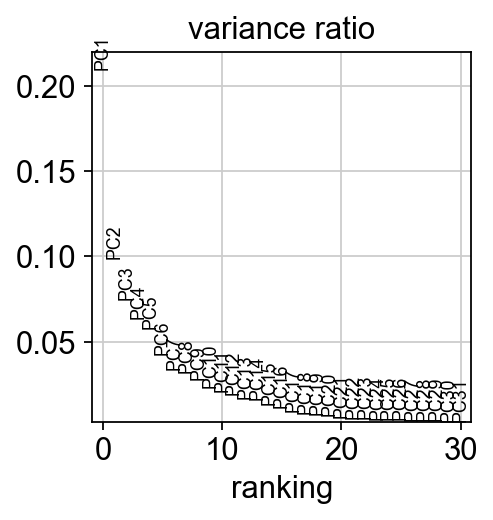

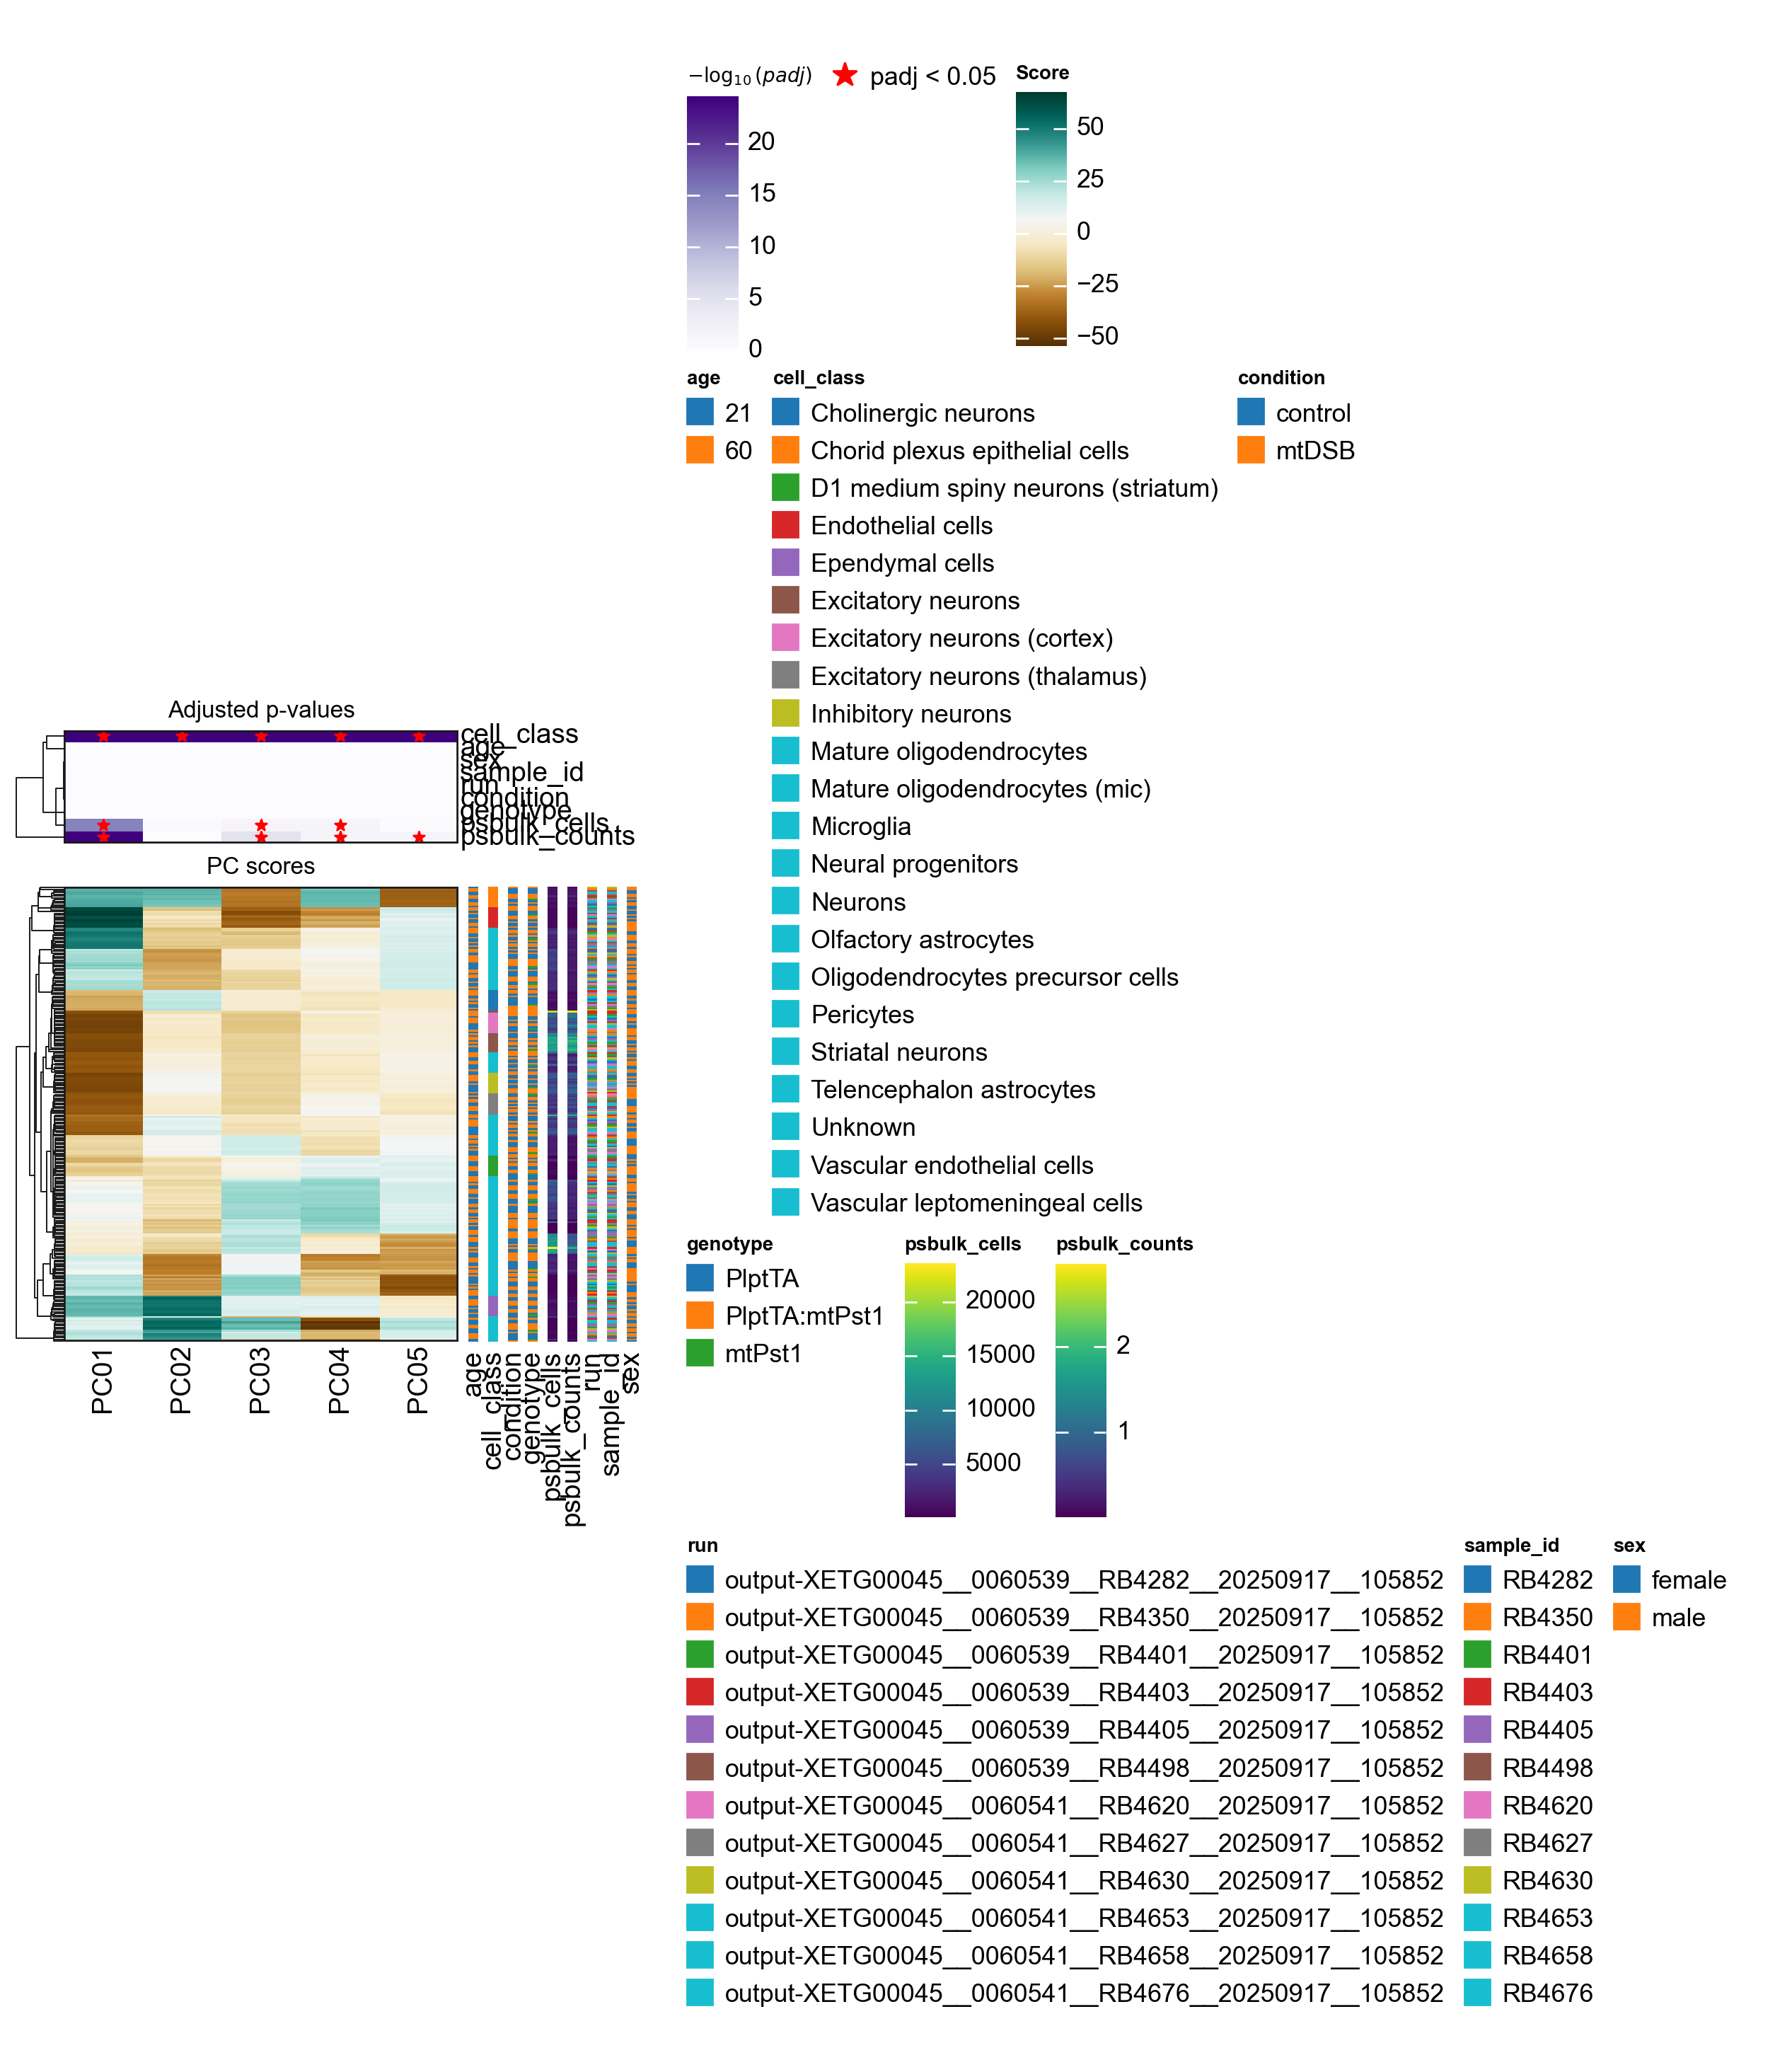

In [39]:
sc.pl.pca_variance_ratio(pdata)
dc.pl.obsm(adata=pdata, return_fig=True, nvar=5, titles=["PC scores", "Adjusted p-values"], figsize=(10, 5))

In [40]:
pdata.obs

,sample_id,cell_class,run,age,sex,genotype,condition,psbulk_cells,psbulk_counts
RB4282_Cholinergic neurons,RB4282,Cholinergic neurons,output-XETG00045__0060539__RB4282__20250917__1...,60,male,PlptTA,control,1697.0,1509843.0
RB4350_Cholinergic neurons,RB4350,Cholinergic neurons,output-XETG00045__0060539__RB4350__20250917__1...,60,male,PlptTA,control,1000.0,863844.0
RB4401_Cholinergic neurons,RB4401,Cholinergic neurons,output-XETG00045__0060539__RB4401__20250917__1...,60,female,PlptTA:mtPst1,mtDSB,1283.0,1029367.0
RB4403_Cholinergic neurons,RB4403,Cholinergic neurons,output-XETG00045__0060539__RB4403__20250917__1...,60,male,PlptTA:mtPst1,mtDSB,1621.0,1513782.0
RB4405_Cholinergic neurons,RB4405,Cholinergic neurons,output-XETG00045__0060539__RB4405__20250917__1...,60,male,PlptTA:mtPst1,mtDSB,742.0,637292.0
...,...,...,...,...,...,...,...,...,...
RB4627_Vascular leptomeningeal cells,RB4627,Vascular leptomeningeal cells,output-XETG00045__0060541__RB4627__20250917__1...,21,male,PlptTA:mtPst1,mtDSB,2735.0,2224655.0
RB4630_Vascular leptomeningeal cells,RB4630,Vascular leptomeningeal cells,output-XETG00045__0060541__RB4630__20250917__1...,21,male,PlptTA:mtPst1,mtDSB,2116.0,2007494.0
RB4653_Vascular leptomeningeal cells,RB4653,Vascular leptomeningeal cells,output-XETG00045__0060541__RB4653__20250917__1...,21,female,PlptTA:mtPst1,mtDSB,2928.0,2524375.0
RB4658_Vascular leptomeningeal cells,RB4658,Vascular leptomeningeal cells,output-XETG00045__0060541__RB4658__20250917__1...,21,female,PlptTA,control,3319.0,2871227.0


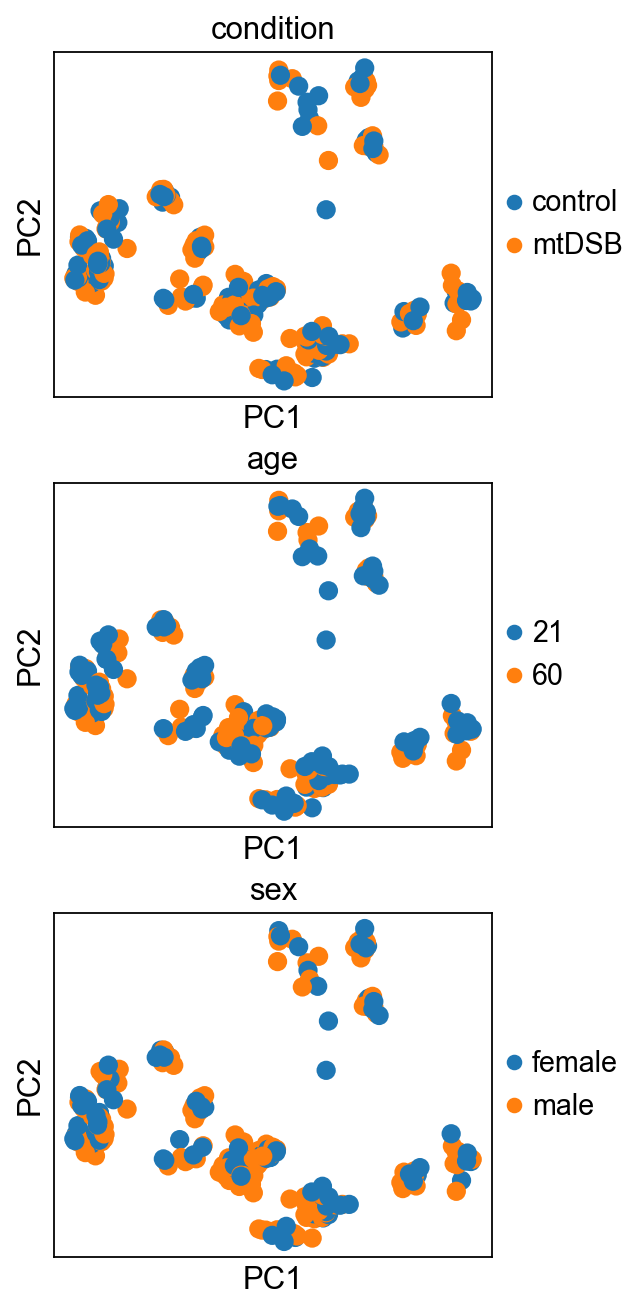

In [41]:
sc.pl.pca(
    pdata,
    color=[ "condition", 'age', 'sex'],
    ncols=1,
    size=300,
    frameon=True,
)

In [42]:
OL = pdata[pdata.obs['cell_class'] == 'Mature oligodendrocytes'].copy()


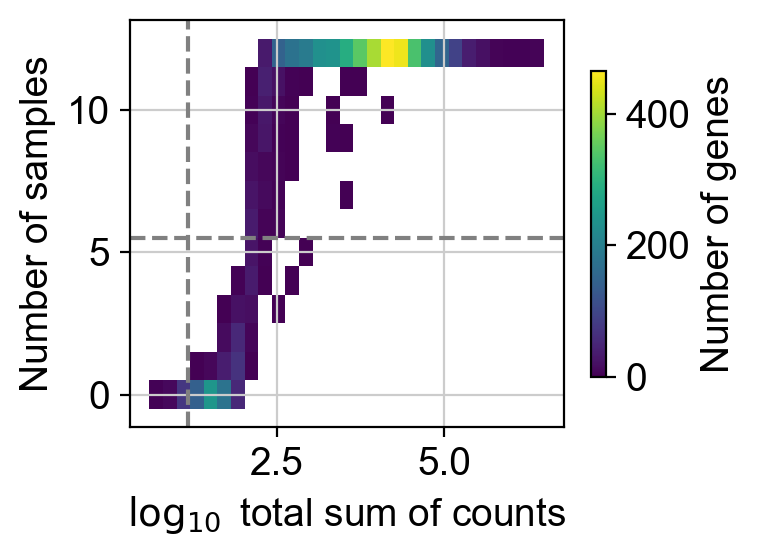

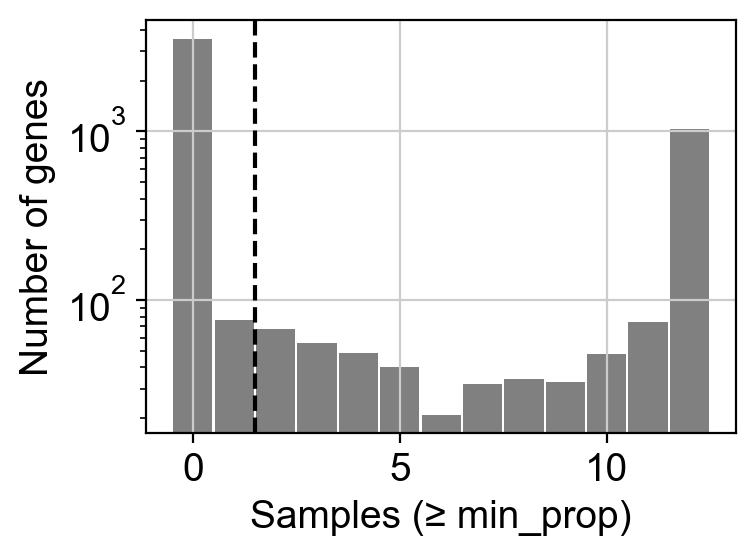

In [43]:
dc.pl.filter_by_expr(
    adata=OL,
    group="condition",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pl.filter_by_prop(
    adata=OL,
    min_prop=0.1,
    min_smpls=2,
)

In [44]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=OL,
    design_factors=["condition"],
    refit_cooks=True,
    inference=inference,
)

# Compute LFCs
dds.deseq2()

# Extract contrast between conditions
stat_res = DeseqStats(dds, contrast=["condition", "mtDSB", "control"], inference=inference)

# Compute Wald test
stat_res.summary()

Using None as control genes, passed at DeseqDataSet initialization


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_68171/900566943.py:7: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.20 seconds.

Fitting dispersion trend curve...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.23 seconds.

Fitting LFCs...
... done in 0.13 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition mtDSB vs control
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Tnfsf9      19.756997        0.740683  0.272317  2.719930  0.006530  0.415689
Adcy1     3621.755559       -0.111210  0.129030 -0.861888  0.388749  0.989324
Atp6v0d2     4.166937        2.312613  0.890809  2.596083  0.009429  0.472508
Dnm1l     4609.871742        0.040732  0.044613  0.913013  0.361236  0.974477
S100b     2079.952440       -0.091254  0.167913 -0.543462  0.586812  0.989324
...               ...             ...       ...       ...       ...       ...
Prf1         2.319035        0.391380  0.805568  0.485843  0.627078  0.989324
Emsy      1357.520338       -0.056564  0.064372 -0.878715  0.379556  0.987136
Icam1       19.961662       -0.084387  0.306766 -0.275085  0.783251  0.994025
Gldc       149.981016       -0.028268  0.181270 -0.155944  0.876077  0.997266
Atp4a       22.284807        0.326792  0.301034  1.085565  0.277672  0.959895

... done in 0.11 seconds.



In [45]:
# Extract results
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Tnfsf9,19.756997,0.740683,0.272317,2.719930,0.006530,0.415689
Adcy1,3621.755559,-0.111210,0.129030,-0.861888,0.388749,0.989324
Atp6v0d2,4.166937,2.312613,0.890809,2.596083,0.009429,0.472508
Dnm1l,4609.871742,0.040732,0.044613,0.913013,0.361236,0.974477
S100b,2079.952440,-0.091254,0.167913,-0.543462,0.586812,0.989324
...,...,...,...,...,...,...
Prf1,2.319035,0.391380,0.805568,0.485843,0.627078,0.989324
Emsy,1357.520338,-0.056564,0.064372,-0.878715,0.379556,0.987136
Icam1,19.961662,-0.084387,0.306766,-0.275085,0.783251,0.994025
Gldc,149.981016,-0.028268,0.181270,-0.155944,0.876077,0.997266


In [68]:
# Build DESeq2 dataset
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=OL,
    metadata="condition",               # column in adata.obs
    ref_level=["condition", "control"], # reference level
    refit_cooks=True,
    inference=inference,
)

/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_60575/2564099838.py:3: UserWarning: adata was provided; ignoring metadata.
  dds = DeseqDataSet(


In [52]:
import matplotlib.pyplot as plt

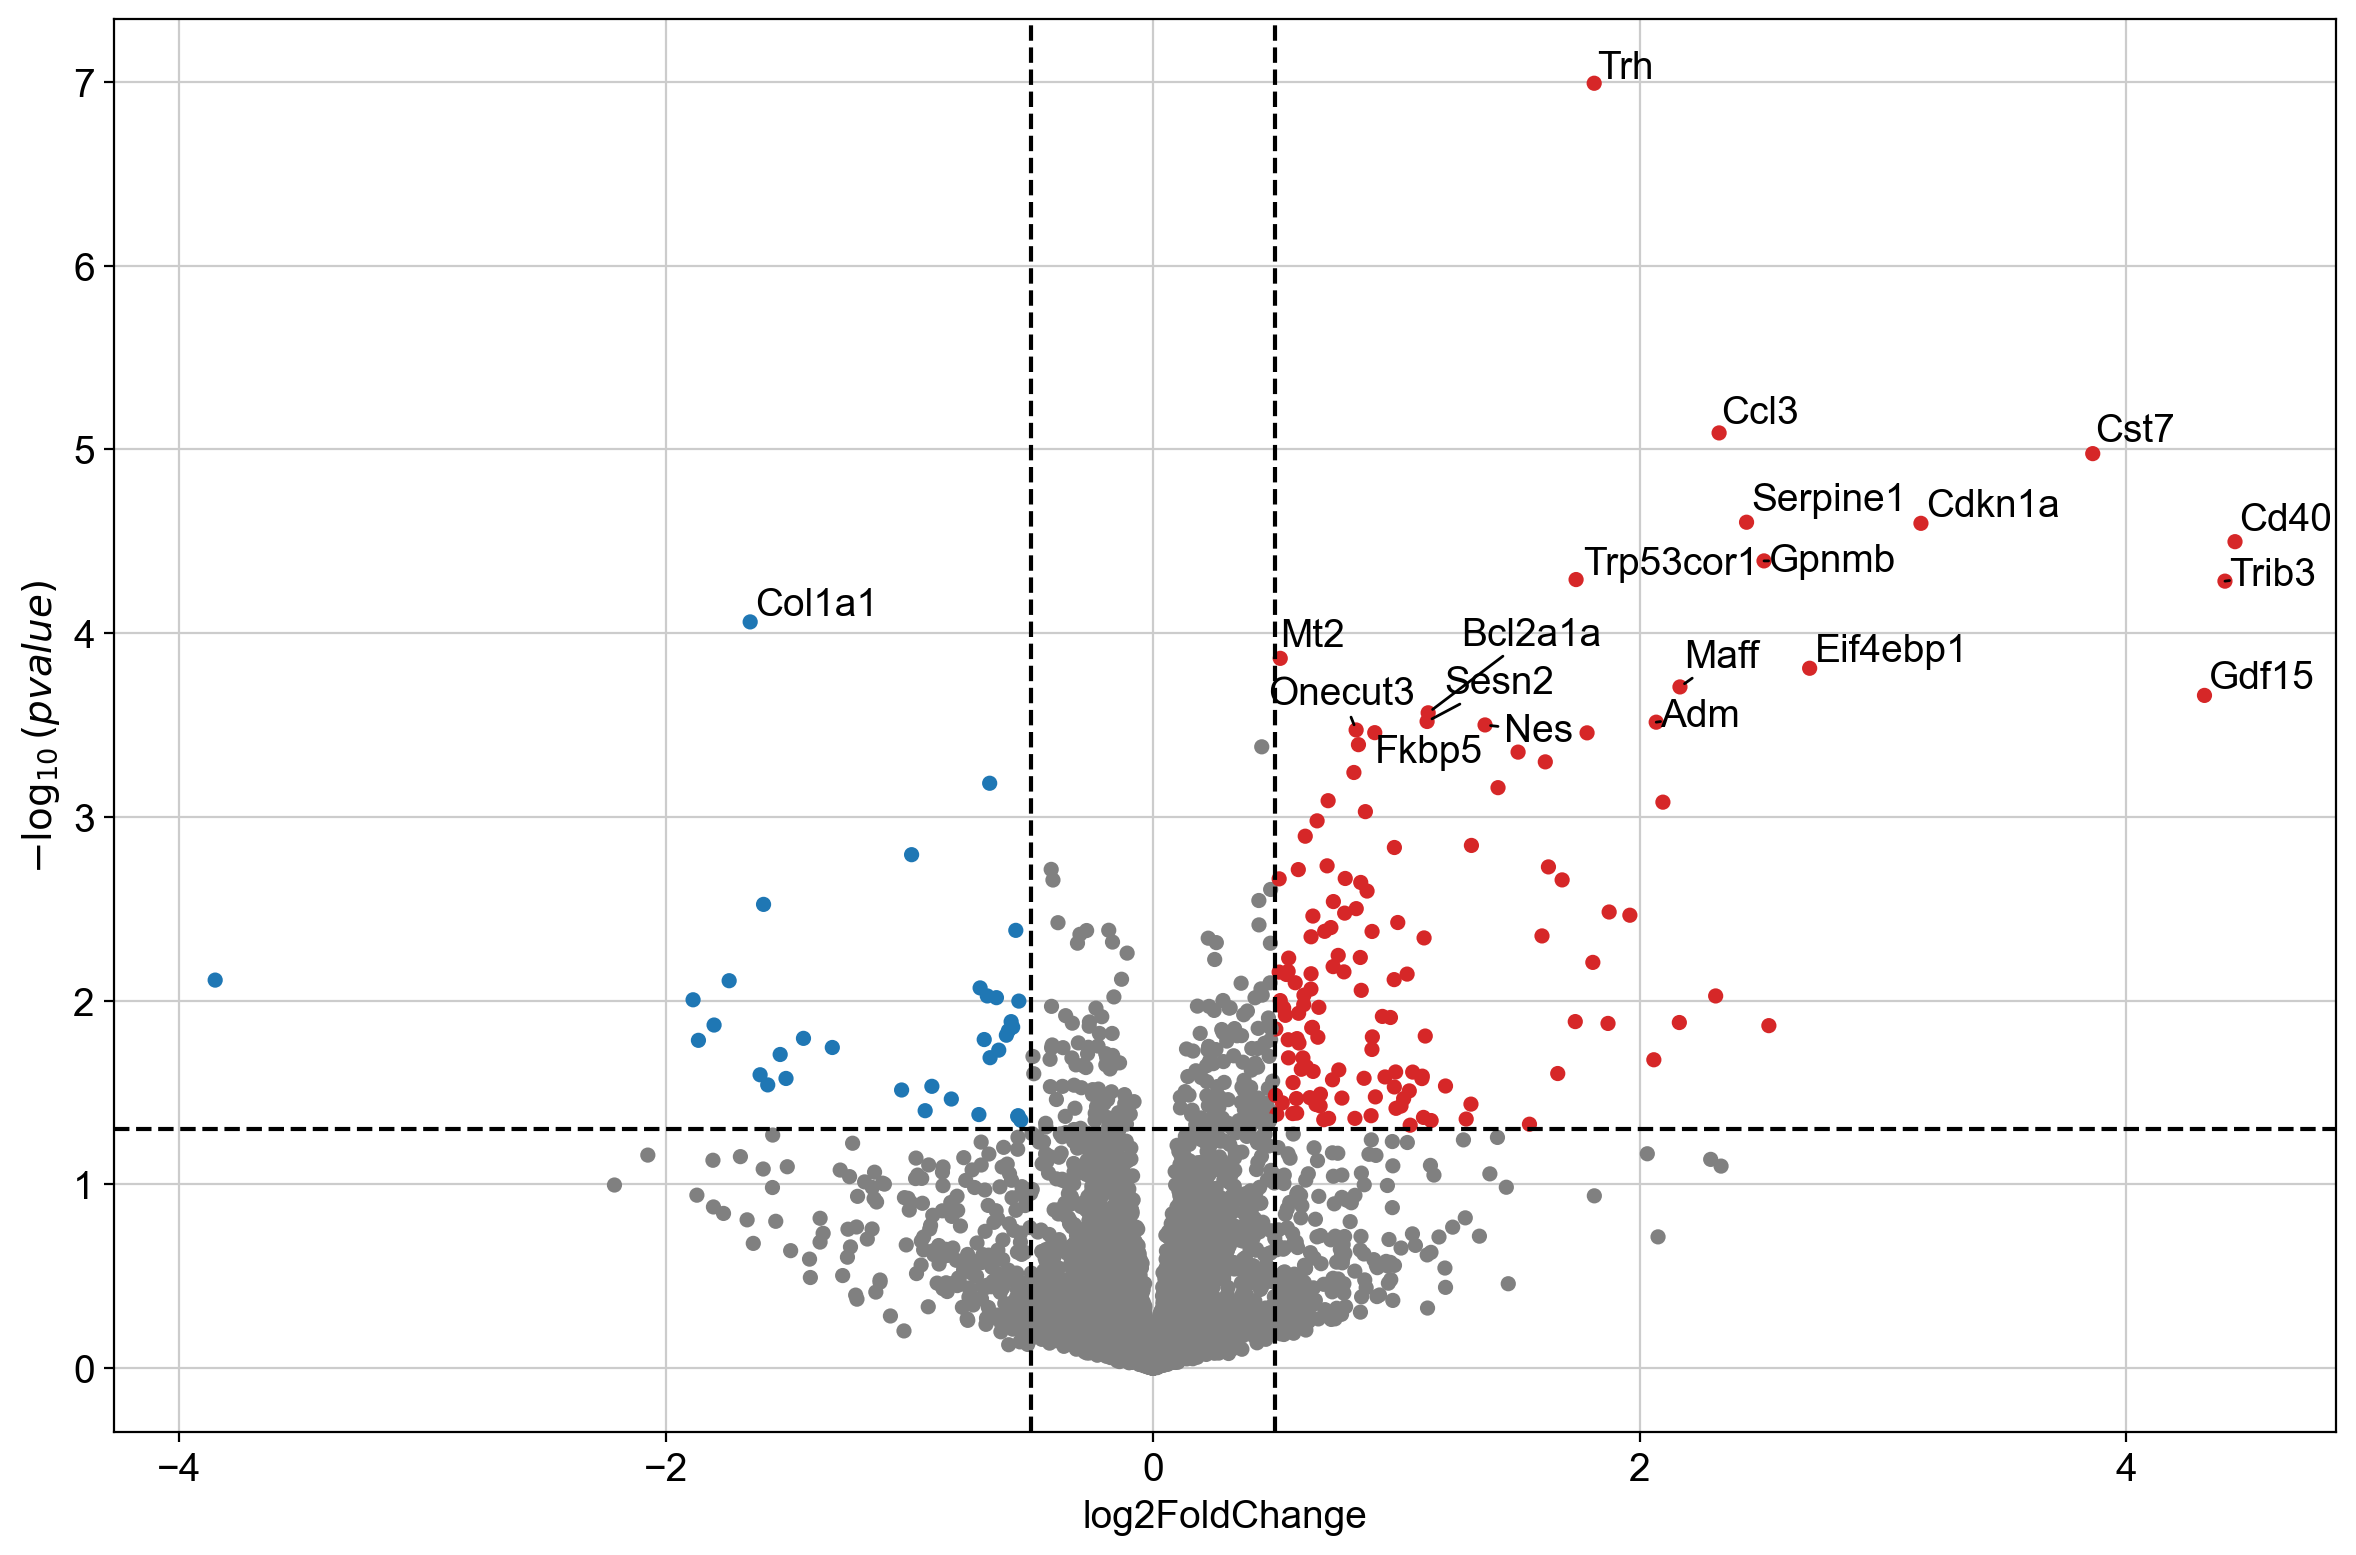

In [63]:
import matplotlib.pyplot as plt
import decoupler as dc

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 6)    
dc.pl.volcano(
        results_df,
        x="log2FoldChange",
        y="pvalue",
        top=20,
    figsize=(12, 8)
    )

In [58]:
data = results_df[["stat"]].T.rename(index={"stat": "disease.vs.normal"})
data

,Tnfsf9,Adcy1,Atp6v0d2,Dnm1l,S100b,Arhgap44,Cdk6,En1,Lamp3,Lamtor1,...,Idh1,Prdm13,Unc93b1,S100a10,Erbb3,Prf1,Emsy,Icam1,Gldc,Atp4a
disease.vs.normal,2.71993,-0.861888,2.596083,0.913013,-0.543462,-0.519405,0.033673,-0.823547,-0.890522,-0.228456,...,-2.093975,1.0317,0.063866,0.498274,-2.027069,0.485843,-0.878715,-0.275085,-0.155944,1.085565


In [59]:
collectri = dc.op.collectri(organism="mouse")
collectri

,source,target,weight,resources,references,sign_decision
0,Myc,Tert,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,Spi1,Bglap3,1.0,ExTRI,10022617,default activation
2,Spi1,Bglap,1.0,ExTRI,10022617,default activation
3,Spi1,Bglap2,1.0,ExTRI,10022617,default activation
4,Smad3,Jun,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
...,...,...,...,...,...,...
43221,Runx1,Lcp2,1.0,DoRothEA-A,20019798,default activation
43222,Runx1,Prr5l,1.0,DoRothEA-A,20019798,default activation
43223,Twist1,Gli1,1.0,DoRothEA-A,11948912,default activation
43224,Usf1,Nup188,1.0,DoRothEA-A,22951020,PMID


In [60]:
# Run
tf_acts, tf_padj = dc.mt.ulm(data=data, net=collectri)

# Filter by sign padj
msk = (tf_padj.T < 0.05).iloc[:, 0]
tf_acts = tf_acts.loc[:, msk]

tf_acts

,Atf4,Atf5,Bmal2,Brca1,Creb1,Elk1,Ets1,Id2,Jund,Kat6a,...,Runx2,Sp1,Sp2,Spi1,Spic,Stat1,Stat3,Stat5a,Stat5b,Tfe3
disease.vs.normal,3.123683,3.200188,3.465366,3.35165,3.37989,5.633993,3.179043,4.791252,3.295182,3.403076,...,-3.125883,3.505027,4.611353,3.544801,3.634105,5.999472,3.568505,3.644335,4.471109,3.737582


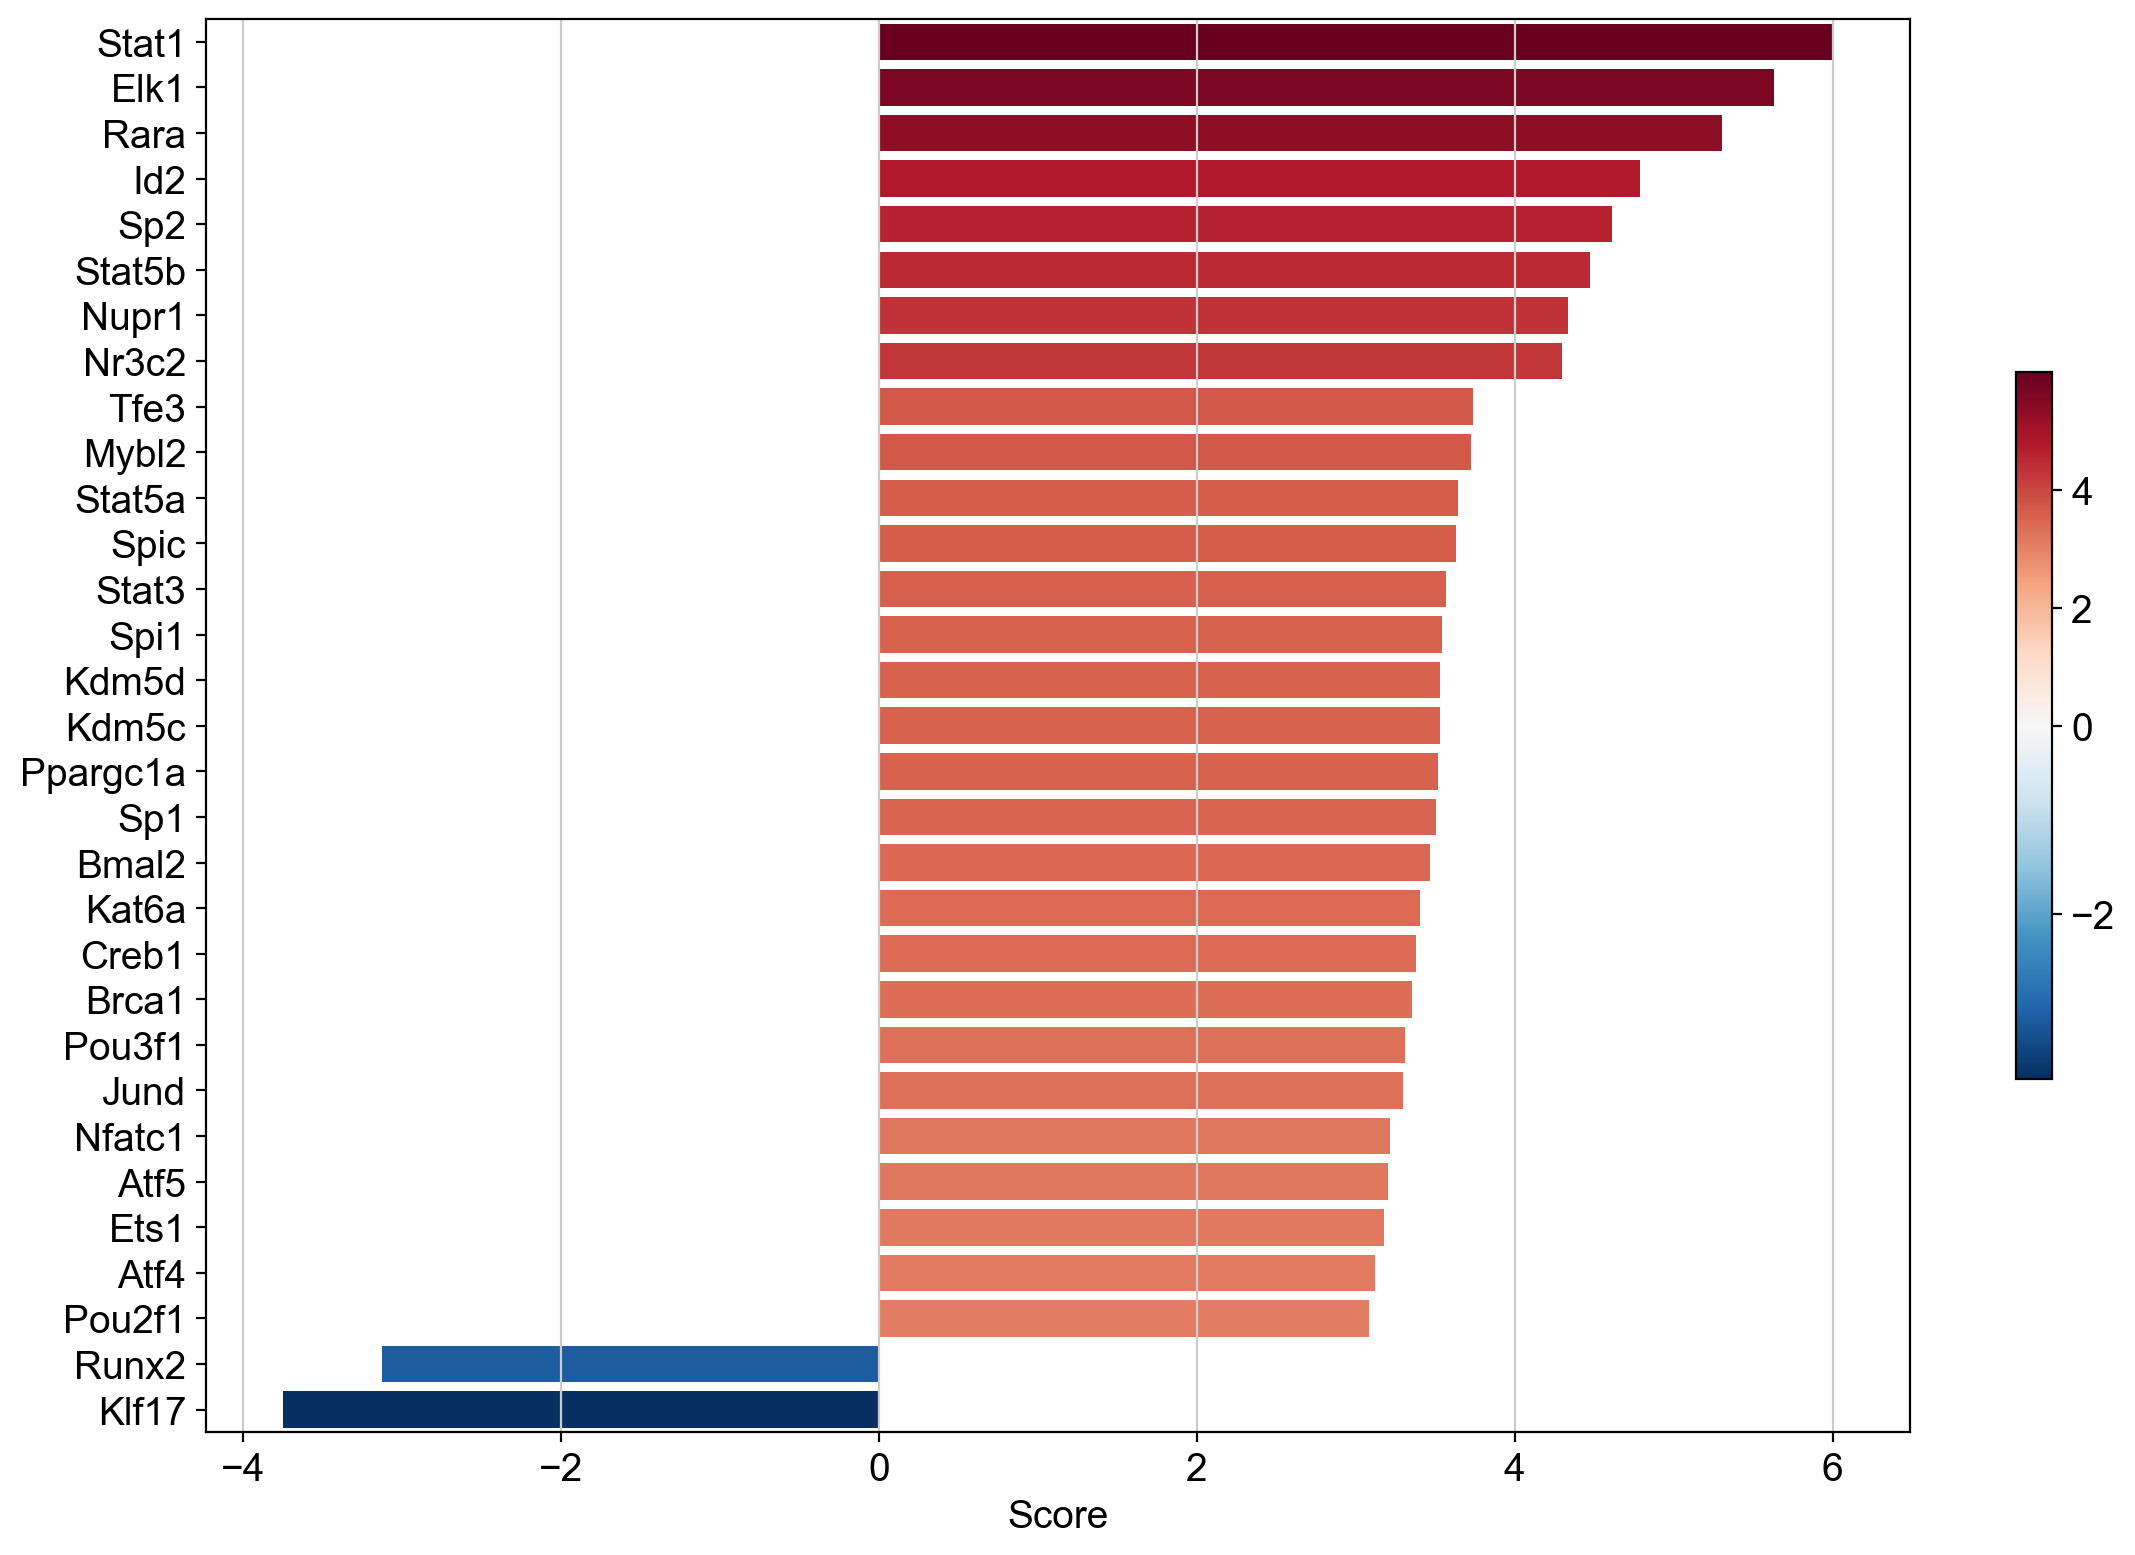

In [66]:
dc.pl.barplot(data=tf_acts, name="disease.vs.normal", figsize=(12, 8), top = 50)

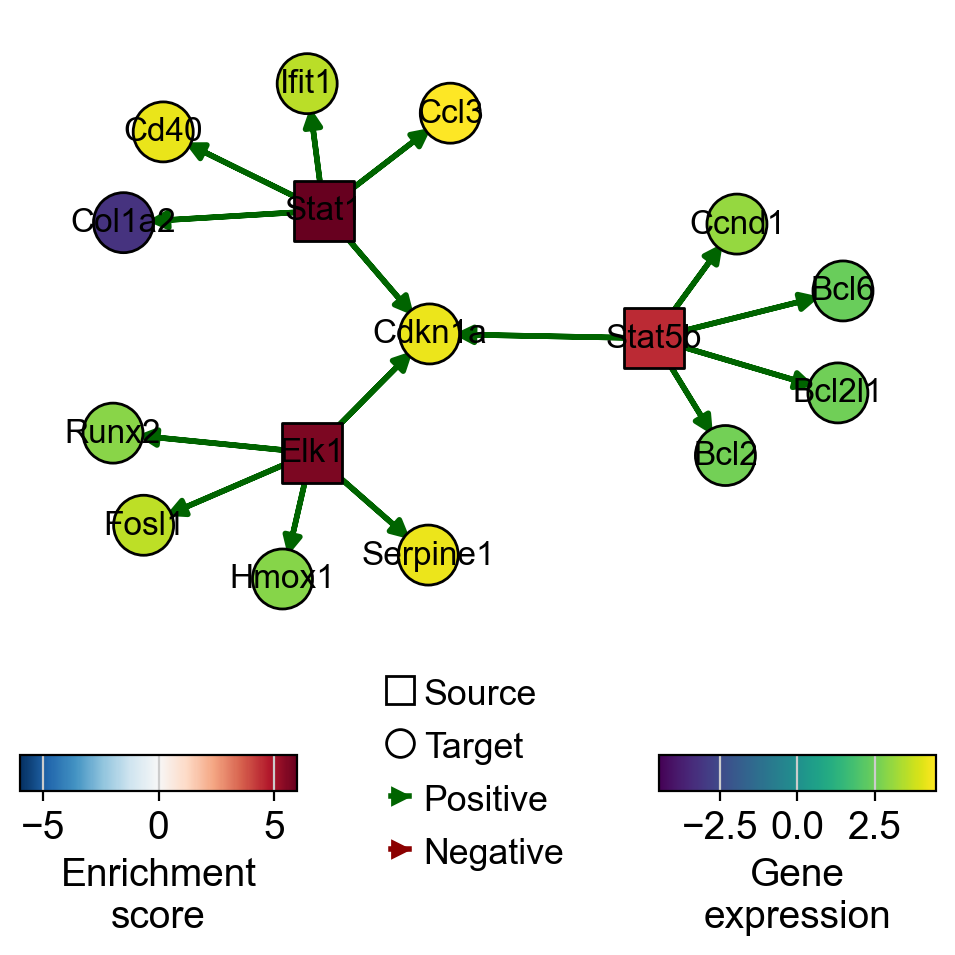

In [67]:
dc.pl.network(
    net=collectri,
    data=data,
    score=tf_acts,
    sources=["Stat1", "Elk1", "Stat5b", "Myc"],
    targets=5,
    figsize=(5, 5),
    vcenter=True,
    by_abs=True,
    size_node=15,
)

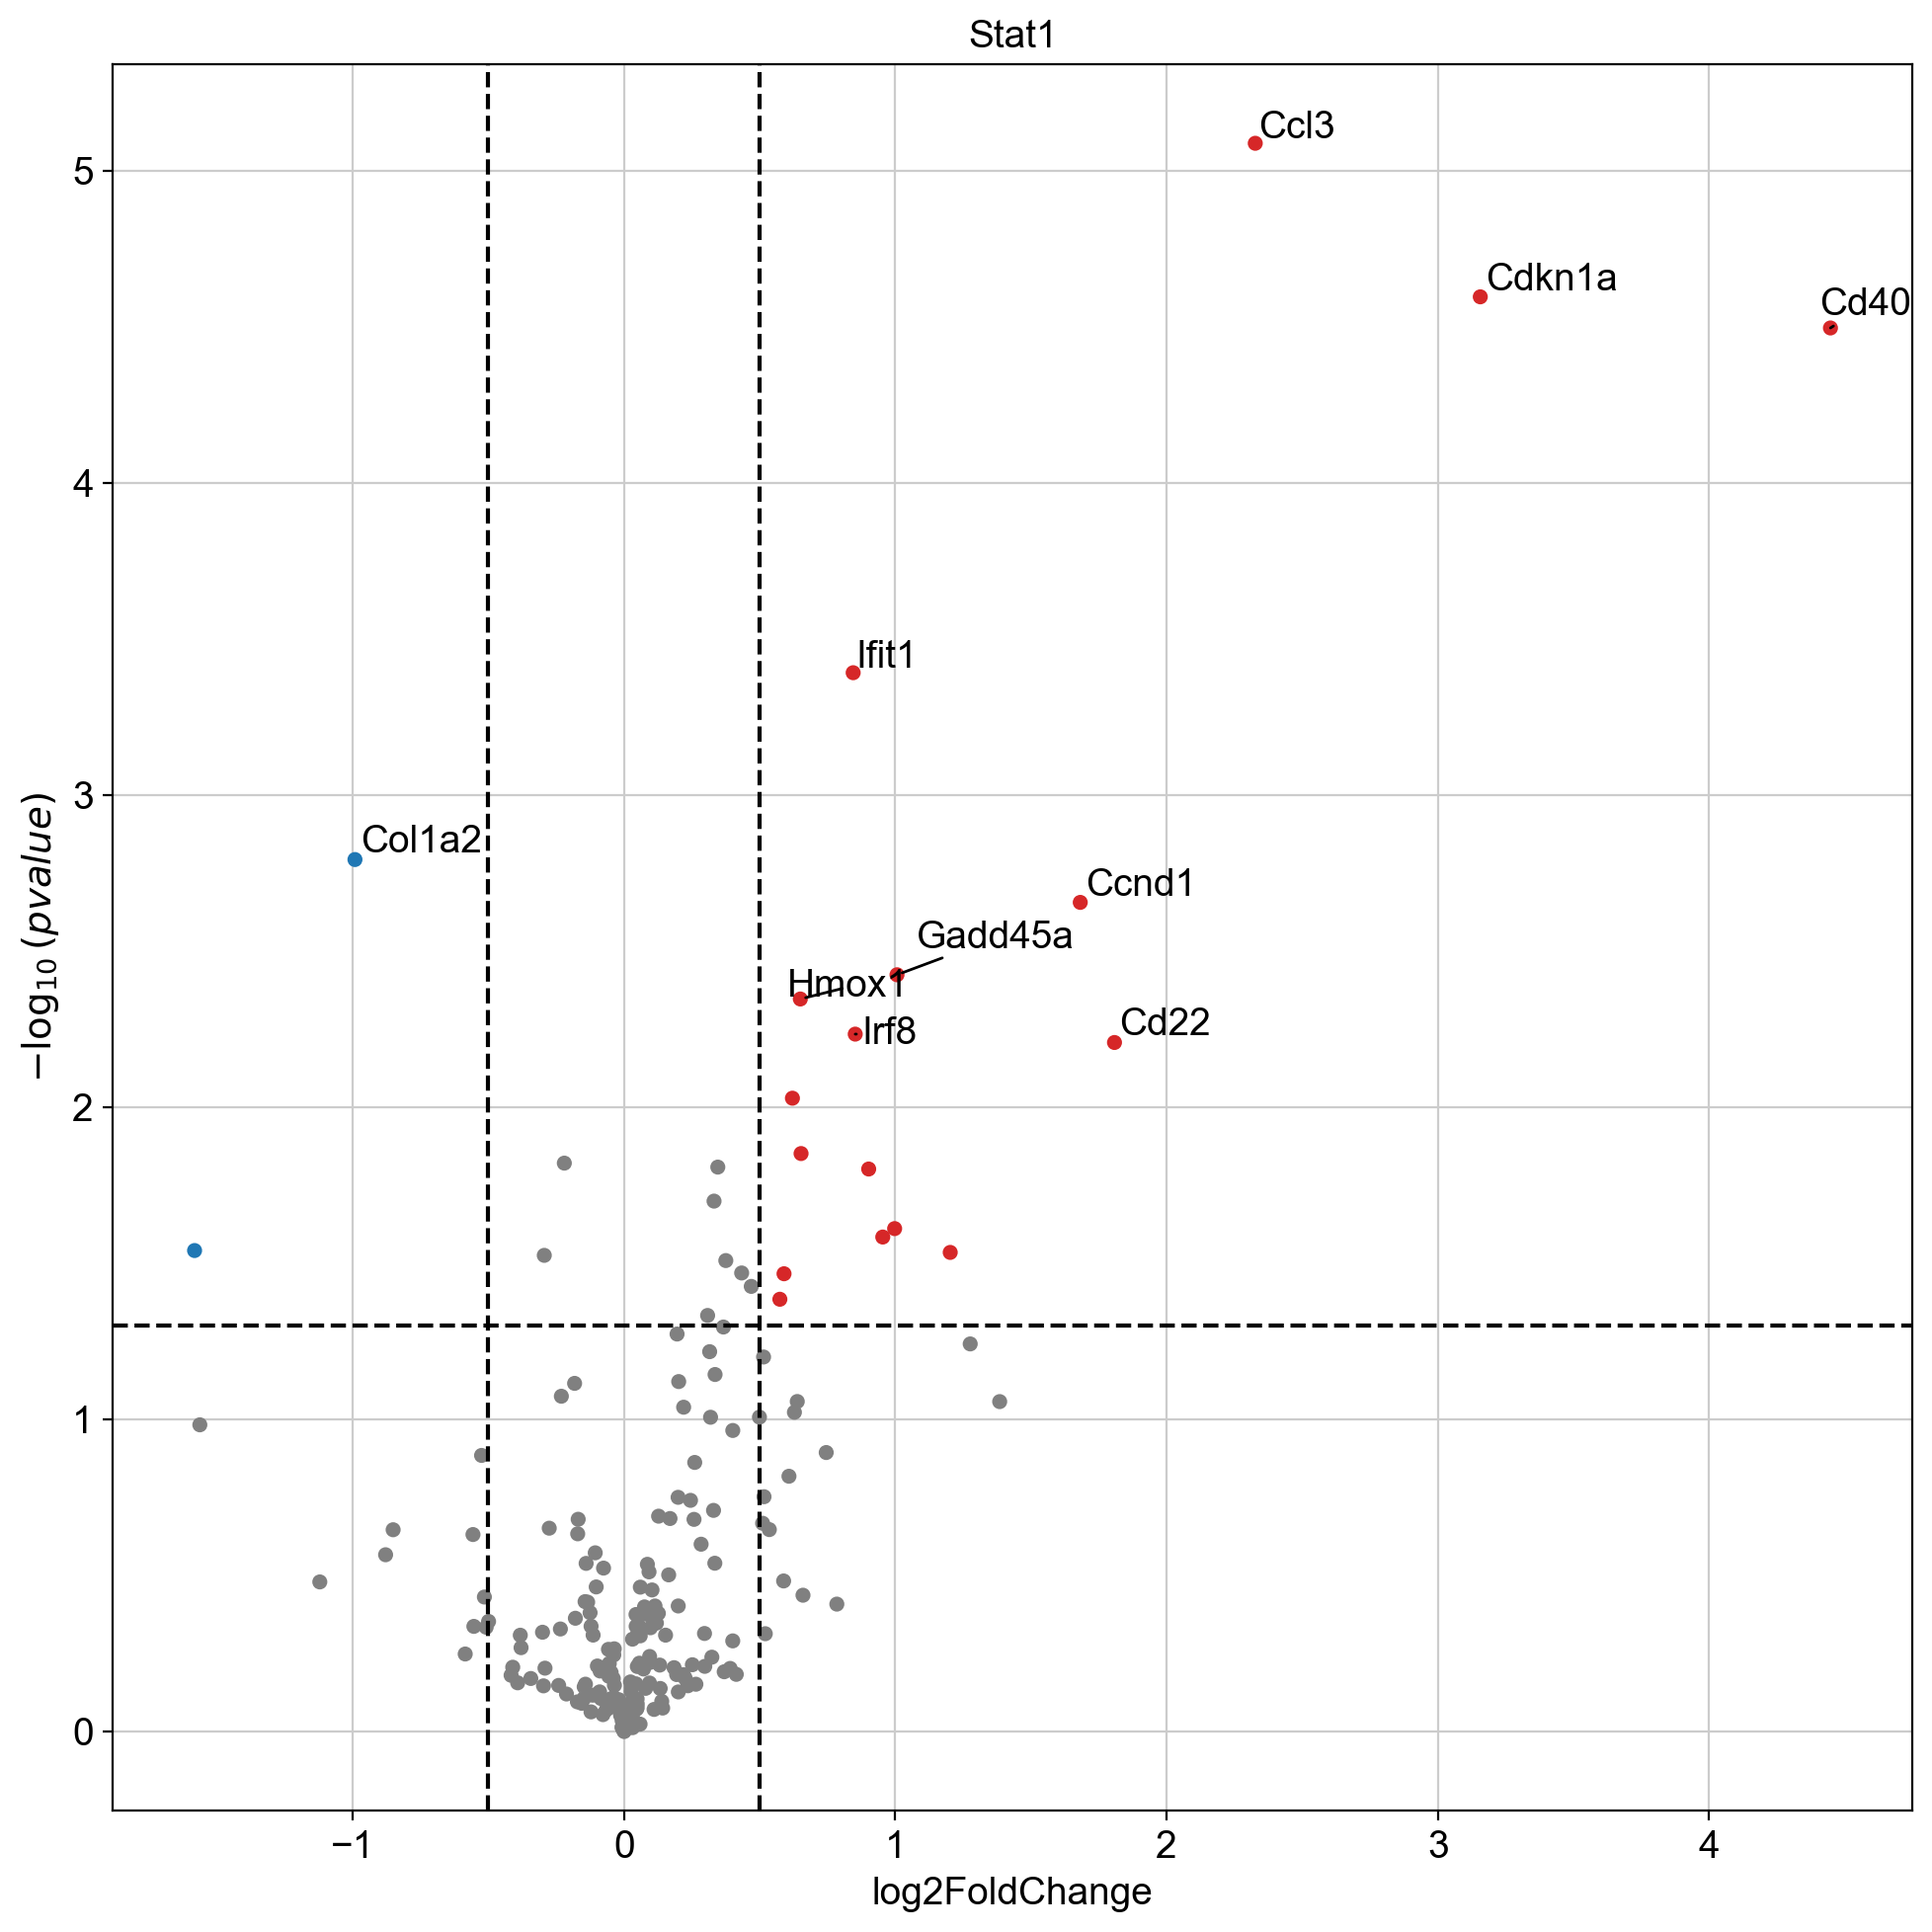

In [71]:
dc.pl.volcano(
    data=results_df,
    x="log2FoldChange",
    y="pvalue",
    net=collectri,
    name="Stat1",
    top=10,
    figsize=(10, 10),
)

In [72]:
progeny = dc.op.progeny(organism="mouse")
progeny

,source,target,weight,padj
0,Androgen,Tmprss2,11.490631,2.384806e-47
1,Androgen,Nkx3-1,10.622551,2.205102e-44
2,Androgen,Mboat2,10.472733,4.632376e-44
3,Androgen,Slc38a4,7.363805,1.253071e-39
4,Androgen,Mtmr9,6.130646,2.534403e-38
...,...,...,...,...
60716,p53,Enpp2,2.771405,4.993215e-02
60717,p53,Arrdc4,3.494328,4.996747e-02
60718,p53,Myo1b,-1.148057,4.997905e-02
60719,p53,Ctsc,-1.784693,4.998864e-02


In [73]:
# Run
pw_acts, pw_padj = dc.mt.ulm(data=data, net=progeny)

# Filter by sign padj
msk = (pw_padj.T < 0.05).iloc[:, 0]
pw_acts = pw_acts.loc[:, msk]

pw_acts

,EGFR,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TNFa,VEGF,p53
disease.vs.normal,7.483428,3.020377,4.599844,8.067228,4.289872,3.034443,2.767393,5.099046,3.561587


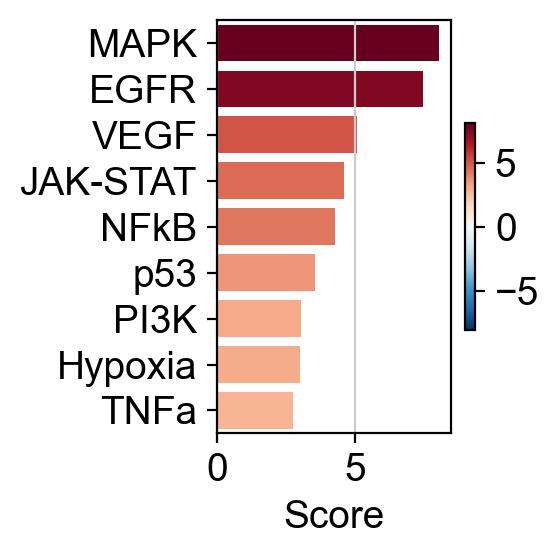

In [74]:
dc.pl.barplot(data=pw_acts, name="disease.vs.normal", figsize=(3, 3))


In [76]:
import numpy as np

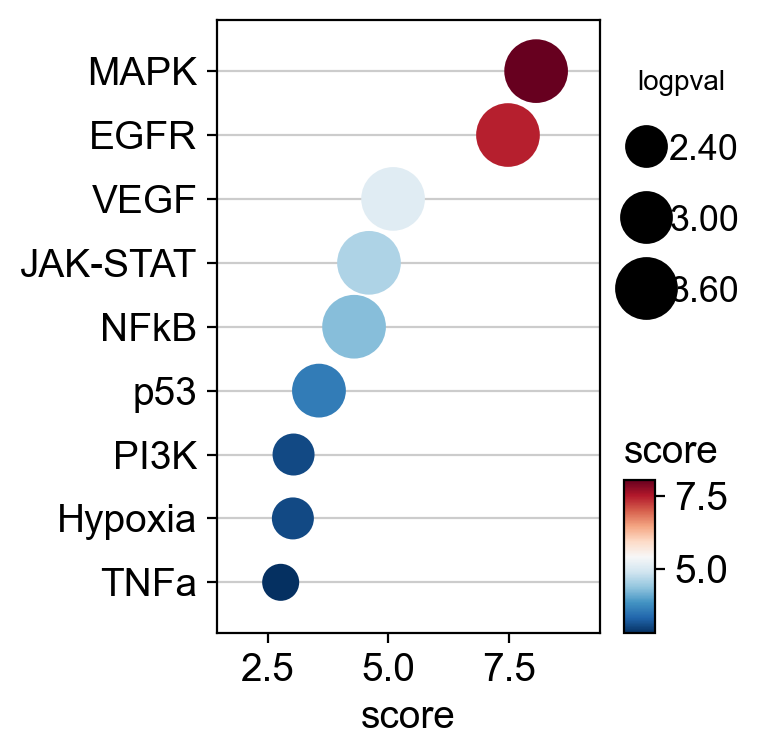

In [77]:
# Transform to df
df = pw_acts.melt(value_name="score").merge(
    pw_padj.melt(value_name="pvalue")
    .assign(logpval=lambda x: x["pvalue"].clip(2.22e-4, 1))
    .assign(logpval=lambda x: -np.log10(x["logpval"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="logpval", c="score", scale=1, figsize=(4, 4))

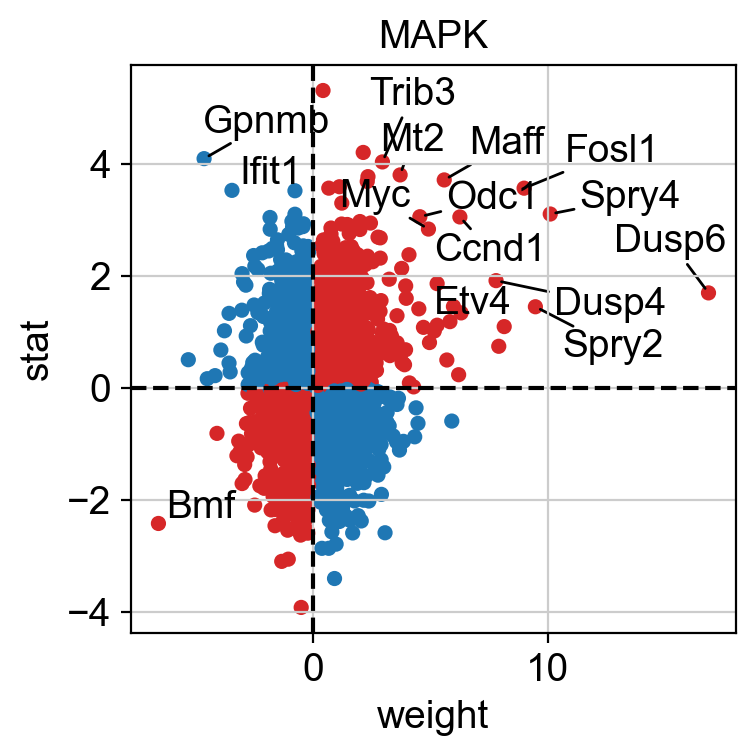

In [80]:
dc.pl.source_targets(data=results_df, x="weight", y="stat", net=progeny, name="MAPK", top=15, figsize=(4, 4))


(+) leading edge: ['Trh' 'Serpine1' 'Trib3' 'Mt2' 'Eif4ebp1']
(-) leading edge: ['Col1a1' 'Aspa' 'Plekha2' 'Smad6' 'Opalin']


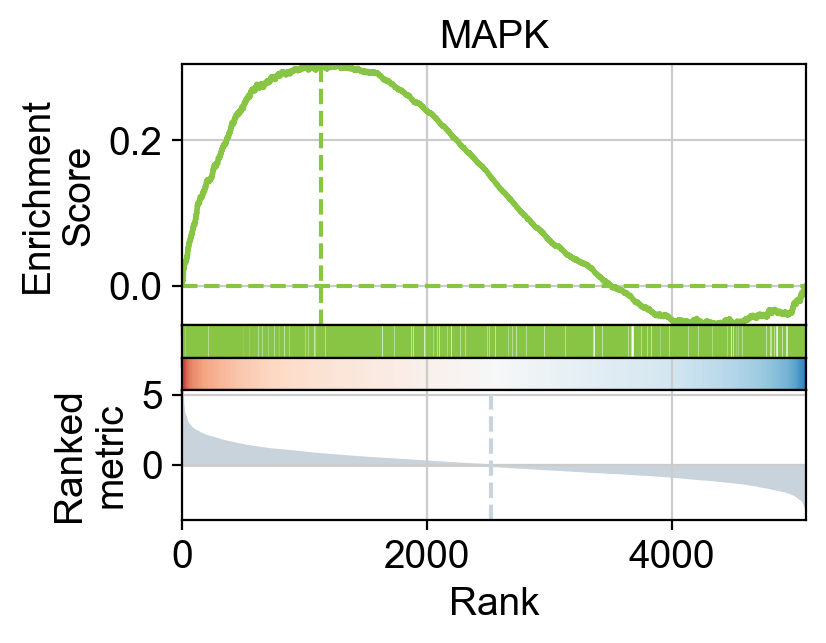

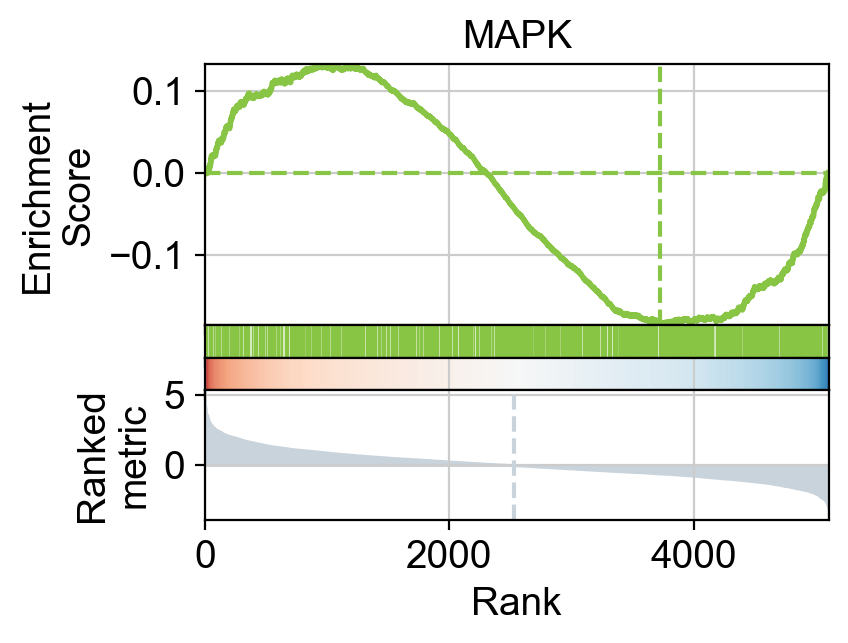

In [81]:
_, pos_le = dc.pl.leading_edge(
    results_df,
    stat="stat",
    net=progeny[progeny["weight"] > 0],
    name="MAPK",
)
print("(+) leading edge:", pos_le[:5])
_, neg_le = dc.pl.leading_edge(
    results_df,
    stat="stat",
    net=progeny[progeny["weight"] < 0],
    name="MAPK",
)
print("(-) leading edge:", neg_le[:5])

In [82]:
hallmark = dc.op.hallmark(organism="mouse")
hallmark

,source,target
0,IL2_STAT5_SIGNALING,Maff
1,COAGULATION,Maff
2,HYPOXIA,Maff
3,TNFA_SIGNALING_VIA_NFKB,Maff
4,COMPLEMENT,Maff
...,...,...
7606,PANCREAS_BETA_CELLS,Stxbp1
7607,PANCREAS_BETA_CELLS,Elp4
7608,PANCREAS_BETA_CELLS,Gcg
7609,PANCREAS_BETA_CELLS,Pcsk2


In [83]:
# Run
hm_acts, hm_padj = dc.mt.ulm(data=data, net=hallmark)

# Filter by sign padj
msk = (hm_padj.T < 0.05).iloc[:, 0]
hm_acts = hm_acts.loc[:, msk]

hm_acts

,ALLOGRAFT_REJECTION,APOPTOSIS,BILE_ACID_METABOLISM,E2F_TARGETS,GLYCOLYSIS,HYPOXIA,IL2_STAT5_SIGNALING,IL6_JAK_STAT3_SIGNALING,INFLAMMATORY_RESPONSE,INTERFERON_GAMMA_RESPONSE,MTORC1_SIGNALING,MYC_TARGETS_V1,MYC_TARGETS_V2,NOTCH_SIGNALING,P53_PATHWAY,PEROXISOME,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING
disease.vs.normal,4.209376,3.061577,-2.554177,2.435517,2.873398,6.547062,4.003454,3.38344,3.391682,5.687002,2.607642,4.647948,4.38015,2.783341,6.009121,-2.459443,5.864178,3.566768,2.806243,2.62393


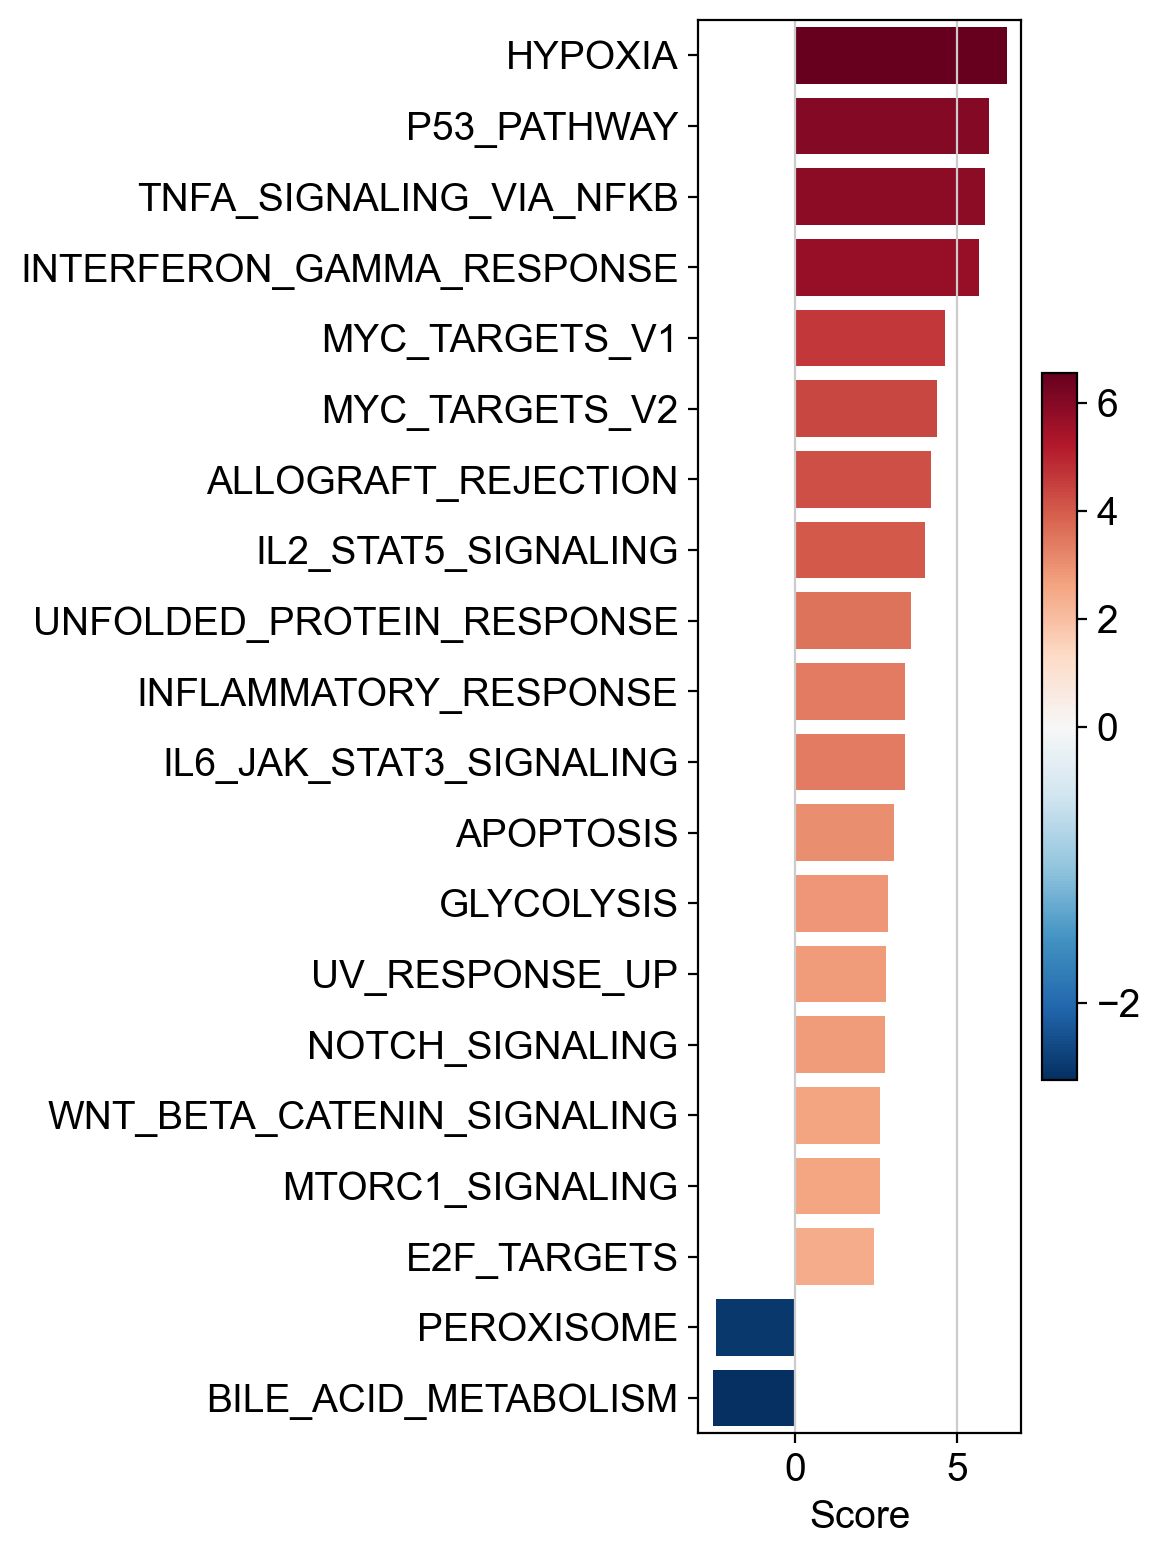

In [87]:
dc.pl.barplot(data=hm_acts, name="disease.vs.normal", figsize=(6, 8))


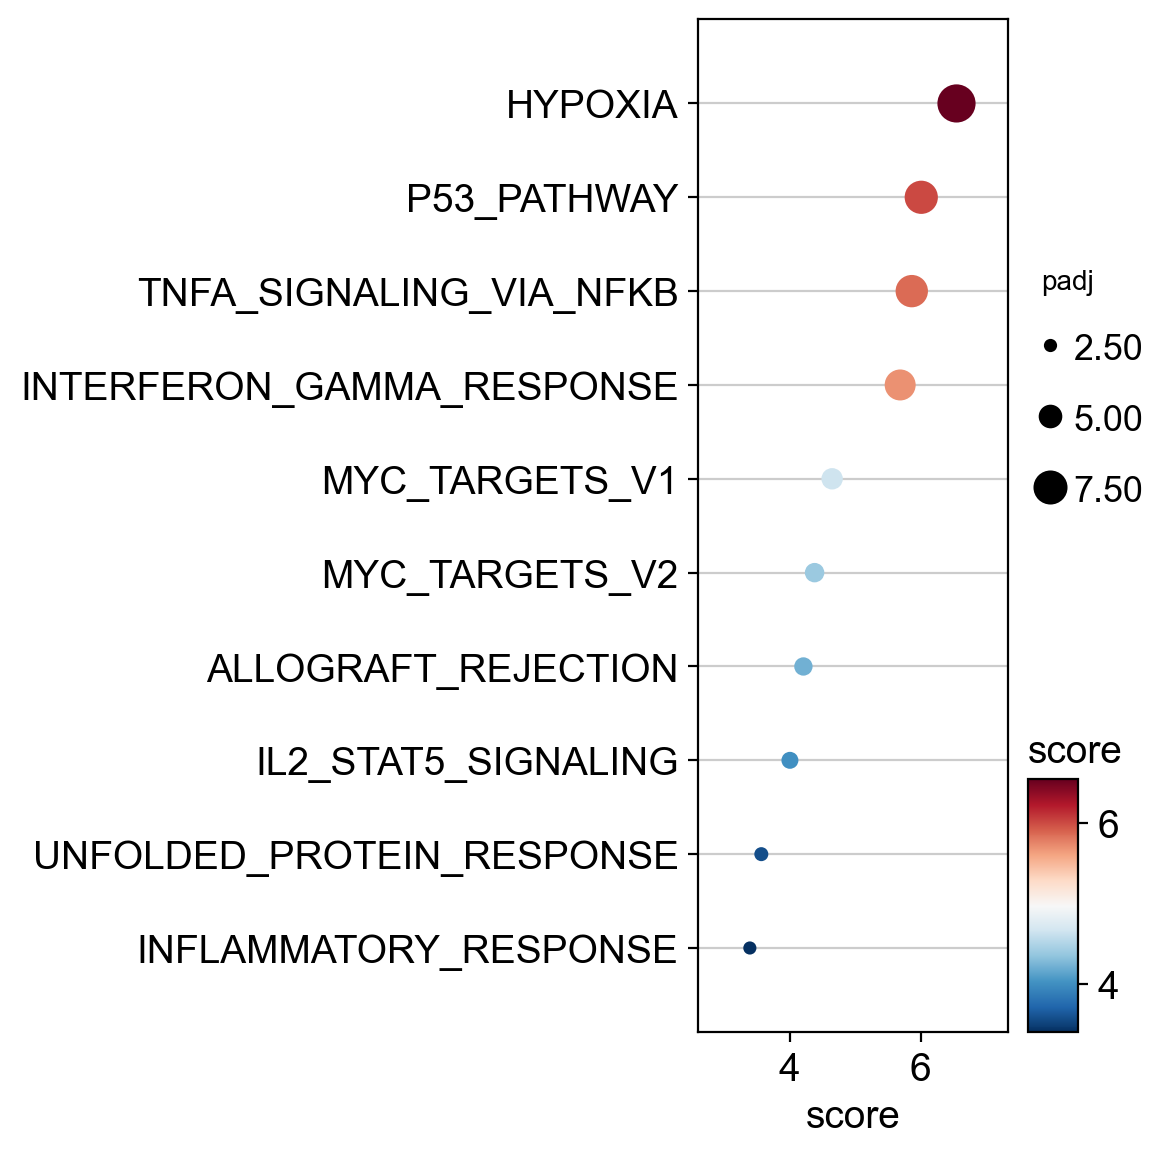

In [90]:
# Tranform to df
df = hm_acts.melt(value_name="score").merge(
    hm_padj.melt(value_name="pvalue")
    .assign(padj=lambda x: x["pvalue"].clip(2.22e-16, 1))
    .assign(padj=lambda x: np.log10(x["pvalue"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="padj", c="score", scale=0.25, figsize=(6, 6))

leading edge: ['Serpine1' 'Cdkn1a' 'Mt2' 'Maff' 'Adm']


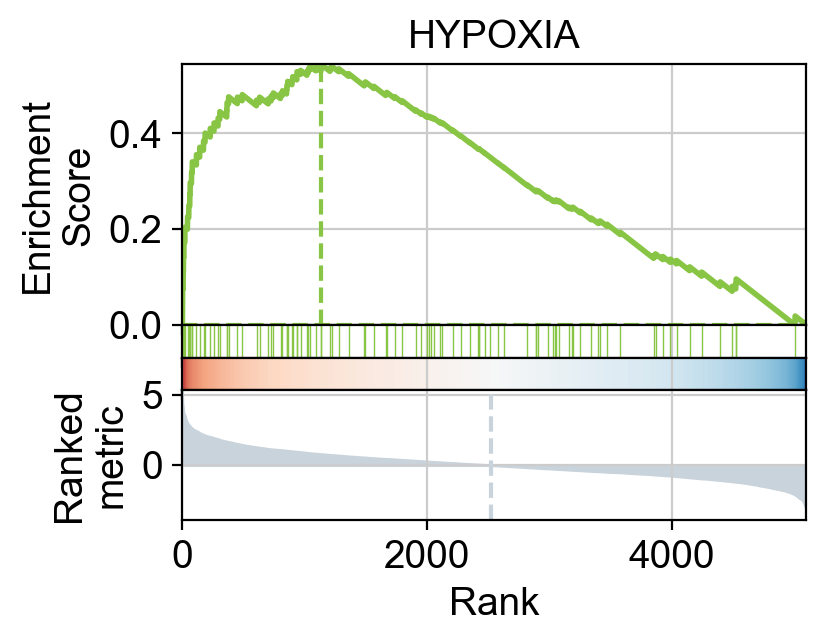

In [92]:
_, le = dc.pl.leading_edge(
    results_df,
    stat="stat",
    net=hallmark,
    name="HYPOXIA",
)
print("leading edge:", le[:5])